# Imersão Dados com Python – Alura (2026)

Este projeto foi desenvolvido durante a **Imersão Dados com Python** da Alura, com aulas guiadas e foco prático em análise de dados utilizando Python.

A análise foi realizada com uma base de dados real contendo **133.349 registros e 11 colunas**, explorando informações sobre cargos, salários, níveis de experiência, trabalho remoto e localização de profissionais da área de dados ao redor do mundo.

## Principais atividades desenvolvidas:

* Importação e manipulação de dados com **Pandas**
* Limpeza e tratamento de dados
* Renomeação e padronização de colunas
* Análise exploratória de dados
* Criação e customização de gráficos com **Matplotlib** e **Seaborn**
* Desenvolvimento de **visualizações interativas** com apoio de IA

## Objetivo

Consolidar conhecimentos iniciais em **Análise de Dados com Python**, compreendendo na prática o fluxo de um projeto de dados — desde a preparação dos dados até a geração de insights por meio de visualizações.

Este projeto faz parte do meu processo de aprendizado na área de dados, com foco em desenvolver autonomia para análises futuras e projetos aplicados.


In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv") #read = ler

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv"

df = pd.read_csv(url)

df.to_csv('salaries.csv', index=False)

In [3]:
df.head(10)  #head = cabeça, líder, topo.

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M
7,2025.0,SE,FT,Data Scientist,148000,USD,148000,US,0,US,M
8,2025.0,MI,FT,Data Scientist,135000,USD,135000,CA,0,CA,M
9,2025.0,MI,FT,Data Scientist,108000,USD,108000,CA,0,CA,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [5]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [6]:
df.shape  #shape = forma, condiçaõ física

(133349, 11)

In [7]:
colunas_traduzidas = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}

df = df.rename(columns=colunas_traduzidas)
print('Colunas após renomear:', df.columns)

Colunas após renomear: Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')


In [8]:
senioridade = {
    'SE': 'Sênior',
    'MI': 'Pleno',
    'EN': 'Júnior',
    'EX': 'Executivo'
}

df['senioridade'] = df['senioridade'].replace(senioridade)
print('Senioridade após tradução:', df['senioridade'].value_counts())

Senioridade após tradução: senioridade
Sênior       77241
Pleno        40465
Júnior       12443
Executivo     3200
Name: count, dtype: int64


In [9]:
contrato = {
    'FT': 'Tempo Integral',
    'CT': 'Contrato',
    'PT': 'Meio Período',
    'FL': 'Freelancer'
}

df['contrato'] = df['contrato'].replace(contrato)
print('Contrato após tradução:', df['contrato'].value_counts())

Contrato após tradução: contrato
Tempo Integral    132563
Contrato             394
Meio Período         376
Freelancer            16
Name: count, dtype: int64


In [10]:
tamanho_empresa = {
    'M': 'Média',
    'L': 'Grande',
    'S': 'Pequena'
}

df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)
print('Tamanho da empresa após tradução:', df['tamanho_empresa'].value_counts())

Tamanho da empresa após tradução: tamanho_empresa
Média      129561
Grande       3574
Pequena       214
Name: count, dtype: int64


In [11]:
remoto = {
    0: 'Presencial',
    100: 'Remoto',
    50: 'Híbrido'
}

df['remoto'] = df['remoto'].replace(remoto)
print('Status remoto após tradução:', df['remoto'].value_counts())

Status remoto após tradução: remoto
Presencial    105312
Remoto         27718
Híbrido          319
Name: count, dtype: int64


In [12]:
df_limpo = df.dropna()
print('Formato do DataFrame após dropar nulos:', df_limpo.shape)

Formato do DataFrame após dropar nulos: (133339, 11)


In [13]:
df.head(10)

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média
5,2025.0,Júnior,Tempo Integral,Data Engineer,80000,USD,80000,US,Presencial,US,Média
6,2025.0,Sênior,Tempo Integral,Data Scientist,185000,USD,185000,US,Presencial,US,Média
7,2025.0,Sênior,Tempo Integral,Data Scientist,148000,USD,148000,US,Presencial,US,Média
8,2025.0,Pleno,Tempo Integral,Data Scientist,135000,USD,135000,CA,Presencial,CA,Média
9,2025.0,Pleno,Tempo Integral,Data Scientist,108000,USD,108000,CA,Presencial,CA,Média


In [14]:
df.info() #vai trazer informações da tabela ex.: non-null = não nulo, ou seja, náo há célula vazia

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senioridade      133349 non-null  object 
 2   contrato         133349 non-null  object 
 3   cargo            133349 non-null  object 
 4   salario          133349 non-null  int64  
 5   moeda            133349 non-null  object 
 6   usd              133349 non-null  int64  
 7   residencia       133349 non-null  object 
 8   remoto           133349 non-null  object 
 9   empresa          133349 non-null  object 
 10  tamanho_empresa  133349 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 11.2+ MB


In [15]:
df.describe() #describe = descrever

,ano,salario,usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


In [16]:
df.shape #shape = forma, é como minha tabela se apresenta, uma análise quantidade discreta de linhas e colunas.

(133349, 11)

In [17]:
linhas, colunas = df.shape[0], df.shape[1]
print('linhas:', linhas)
print('colunas:', colunas)

linhas: 133349
colunas: 11


In [18]:
df.columns #columns = colunas, vai mostrar o nome das colunas.

Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')

In [19]:
colunas_traduzidas = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}

df = df.rename(columns=colunas_traduzidas)
print(df.columns)

Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')


In [20]:
df['ano'].value_counts()

ano
2024.0    62240
2025.0    60627
2023.0     8521
2022.0     1660
2021.0      216
2020.0       75
Name: count, dtype: int64

In [21]:
df['senioridade'].value_counts()  #value = valor; caunts = contagem

senioridade
Sênior       77241
Pleno        40465
Júnior       12443
Executivo     3200
Name: count, dtype: int64

In [22]:
df['contrato'].value_counts()

contrato
Tempo Integral    132563
Contrato             394
Meio Período         376
Freelancer            16
Name: count, dtype: int64

In [23]:
df['remoto'].value_counts()

remoto
Presencial    105312
Remoto         27718
Híbrido          319
Name: count, dtype: int64

0 = presenciais;
100 = remota;
50 = híbridas.

In [24]:
df['tamanho_empresa'].value_counts()

tamanho_empresa
Média      129561
Grande       3574
Pequena       214
Name: count, dtype: int64

M (MEDIUM)-> médio; L (LARGE)-> grande; S (SMALL)-> pequena

In [25]:
senioridade = {
    'SE': 'Sênior',
    'MI': 'Pleno',
    'EN': 'Júnior',
    'EX': 'Executivo'
}

df['senioridade'] = df['senioridade'].replace(senioridade)
print(df['senioridade'].value_counts())

senioridade
Sênior       77241
Pleno        40465
Júnior       12443
Executivo     3200
Name: count, dtype: int64


In [26]:
contrato = {
    'FT': 'Tempo Integral',
    'CT': 'Contrato',
    'PT': 'Meio Período',
    'FL': 'Freelancer'
}

df['contrato'] = df['contrato'].replace(contrato)
print(df['contrato'].value_counts())

contrato
Tempo Integral    132563
Contrato             394
Meio Período         376
Freelancer            16
Name: count, dtype: int64


In [27]:
tamanho_empresa = {
    'M': 'Média',
    'L': 'Grande',
    'S': 'Pequena'
}

df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)
print(df['tamanho_empresa'].value_counts())

tamanho_empresa
Média      129561
Grande       3574
Pequena       214
Name: count, dtype: int64


In [28]:
remoto = {
    0: 'Presencial',
    100: 'Remoto',
    50: 'Híbrido'
}

df['remoto'] = df['remoto'].replace(remoto)
print(df['remoto'].value_counts())

remoto
Presencial    105312
Remoto         27718
Híbrido          319
Name: count, dtype: int64


In [29]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [30]:
df.describe(include='object')  #describe = descrever; include = incluir;

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Sênior,Tempo Integral,Data Scientist,USD,US,Presencial,US,Média
freq,77241,132563,17314,126140,119579,105312,119641,129561


* count: quantos valores temos para aquela coluna, ou seja estão iguais e está correto;
* unique: valores únicos, exemplo a coluna senioridae possui 4 valores (executivo, sênior, pleno e júnior); remoto (presencial, remoto e híbrido);
* top: qual informação é a mais frequente, exemplo: contrato "mais comum" é o Tempo Integral;
* freq: cáculo da frequência, quantas vezes o valor está se repetindo em relação ao tópico, exemplo: o sênior se repete 77.241 vezes.

In [31]:
df.describe() #esse comando volta a visualização inicial

,ano,salario,usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


#Aula 2 - Preparação e limpeza dos Dados
Capacitar o aluno renomear colunas, identificar e tratar dados faltantes,

In [32]:

df.isnull()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


no df.disnull() apareceram as 5 primeiras e 5 últimas linhas e não aparecem dados nulos (False), mas saõ mais de 133 mil linhas, entaõ vamos recordar nossa base de dados com comando df.head()       [head = cabeça]

In [33]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


agora sim vamos rodar o df.isnul, acrescentando a soma dos valores. A ideia é buscar valores nulos do meu banco de dados: df.isnul().sum()

In [34]:
df.isnull().sum() #foram encontrados 10 linhas que não têm o ano preenchido

ano                10
senioridade         0
contrato            0
cargo               0
salario             0
moeda               0
usd                 0
residencia          0
remoto              0
empresa             0
tamanho_empresa     0
dtype: int64

In [35]:
df['ano'].unique()  #not a number (nan)

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [36]:
df[df.isnull().any(axis=1)] #vai criar um outro filtro com tudo que é nulo e só vai exibir essas, 10 informações com o 'ano' ausente.

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,Sênior,Tempo Integral,Product Manager,184500,USD,184500,US,Presencial,US,Média
59692,NaN,Pleno,Tempo Integral,Engineer,110000,USD,110000,DE,Presencial,DE,Média
59710,NaN,Júnior,Tempo Integral,Data Scientist,208800,USD,208800,US,Presencial,US,Média
59759,NaN,Sênior,Tempo Integral,Software Engineer,135000,USD,135000,US,Presencial,US,Média
59789,NaN,Sênior,Tempo Integral,Engineer,112000,USD,112000,US,Presencial,US,Média
131000,NaN,Sênior,Tempo Integral,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,Média
131006,NaN,Sênior,Tempo Integral,Data Analytics Manager,204500,USD,204500,US,Presencial,US,Média
133054,NaN,Júnior,Tempo Integral,Data Scientist,40000,USD,40000,JP,Remoto,MY,Grande
133281,NaN,Pleno,Tempo Integral,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,Grande
133317,NaN,Pleno,Tempo Integral,Data Scientist,130000,USD,130000,US,Híbrido,US,Grande


##começo da base inteira(df), mas farei um filtro(df.isnull) de tudo que é nulo e farei mais um filtro para aparecer só as que eu quero(.any(axis=1))
##as colunas apreceram as que tem o 'ano' ausentes nesses dados:
#df[df.isnull().any(axis=1)]  

fazer uma média com 'ano' não faria sentido, então será realizada uma média com os salários. São números e atenderão nossa necessidade:


#ENTÃO AGORA SERÁ CRIADO UM DATAFRAME == df

In [37]:
import numpy as np

#criação de uma basa de dados:
df_salarios = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Daniele', 'Val'],
    'salario': [4000, np.nan, 5000, np.nan, 100000]
})

#calcula a média salarial e substitui os nulos pela média e arredonda valores
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))  #fill = preencher  na = valores nulos -> fillna; roun2 é um arredondamento

'''calcula a mediana e substitui os nulos pela mediana, nesse caso não é afetada por outliers e não precisa arredondar'''
df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())

df_salarios


,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,36333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,36333.33,5000.0
4,Val,100000.0,100000.00,100000.0


#SERÁ REALIZADO AGORA UM OUTRO DATAFRAME DE TEMPERATURAS

In [38]:
import numpy as np

df_temperaturas = pd.DataFrame({
    'Dia': ['segunda', 'terça', 'quarta', 'quinta', 'sexta'],
    'Temperaturas': [30, np.nan, np.nan, 28, 27]
})

df_temperaturas['preenchido_ffill'] = df_temperaturas['Temperaturas'].ffill()
df_temperaturas

,Dia,Temperaturas,preenchido_ffill
0,segunda,30.0,30.0
1,terça,NaN,30.0
2,quarta,NaN,30.0
3,quinta,28.0,28.0
4,sexta,27.0,27.0


Este código cria um DataFrame chamado df_temperaturas e preenche os valores NaN na coluna 'Temperaturas' usando o método ffill(), que propaga o último valor válido para frente.

In [39]:

df_temperaturas['preenchido_bfill'] = df_temperaturas['Temperaturas'].bfill()
df_temperaturas

,Dia,Temperaturas,preenchido_ffill,preenchido_bfill
0,segunda,30.0,30.0,30.0
1,terça,NaN,30.0,28.0
2,quarta,NaN,30.0,28.0
3,quinta,28.0,28.0,28.0
4,sexta,27.0,27.0,27.0


#como no ffil ele pegará (copiará) do primeiro para frente, no bfill vai pegar do último para trás.
#b = back

Agora será realizado um dataframe de pessoas e cidades onde moram, supor que alguma não preencheu e ficou vazio (nulo).


In [40]:
df_cidades = pd.DataFrame({
     'nome': ['Ana', 'Bruno', 'Carlos', 'Daniele', 'Val'],
    'cidades': ['São Paulo', np.nan, 'Curitiba', np.nan, 'Belém']
})

df_cidades['cidades_preenchidas'] = df_cidades['cidades'].fillna('Não informado')
df_cidades

,nome,cidades,cidades_preenchidas
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Daniele,NaN,Não informado
4,Val,Belém,Belém


Para criar uma nova coluna em um DataFrame do Pandas, você precisa usar colchetes e o nome da coluna entre aspas, assim: df_cidades['df_preenchida'] = .... Além disso, é errado usar aspas em 'np.nan' (uma string) na criação do DataFrame, o que não é o mesmo que np.nan (o valor numérico para 'não é um número' do numpy).

No df_temperaturas, você pode ver que os valores NaN foram preenchidos usando o método ffill(), o que significa que a última temperatura válida ('30.0' no caso) foi propagada para preencher os valores ausentes. Já no df_cidades, os valores NaN na coluna 'cidades' foram substituídos pela string 'Não informado'. O resultado final mostra os DataFrames com os valores preenchidos.



VAMOS RETORNAR À TABELA DOS SALÁRIOS E AJUSTAR

In [41]:
df_limpo = df.dropna() #criar o df_limpo (nova variável) o que vai retirar os 10 valores ausentes nos dados.
df_limpo.isnull().sum()

ano                0
senioridade        0
contrato           0
cargo              0
salario            0
moeda              0
usd                0
residencia         0
remoto             0
empresa            0
tamanho_empresa    0
dtype: int64

In [42]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [43]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senioridade      133339 non-null  object 
 2   contrato         133339 non-null  object 
 3   cargo            133339 non-null  object 
 4   salario          133339 non-null  int64  
 5   moeda            133339 non-null  object 
 6   usd              133339 non-null  int64  
 7   residencia       133339 non-null  object 
 8   remoto           133339 non-null  object 
 9   empresa          133339 non-null  object 
 10  tamanho_empresa  133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


observe que o ano aparece como float. Mas como ano é uma variável tipo inteiro, vamos converter o tipo dele

In [44]:
#rodar primeiro este e só depois o de cima.
#ano deixara de ser float e passará a ser int.

df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype('int64'))  #assign = destinar, atribuir, encarregar


# AULA 3
VISUALIZAÇÃO DE DADOS

In [45]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Sênior,Tempo Integral,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Sênior,Tempo Integral,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,Tempo Integral,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,Tempo Integral,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Júnior,Tempo Integral,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [46]:
import os

# Criar pasta para salvar os gráficos dentro do projeto
os.makedirs('graficos', exist_ok=True)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<Axes: title={'center': 'Distribuição de senioridade'}, xlabel='senioridade'>

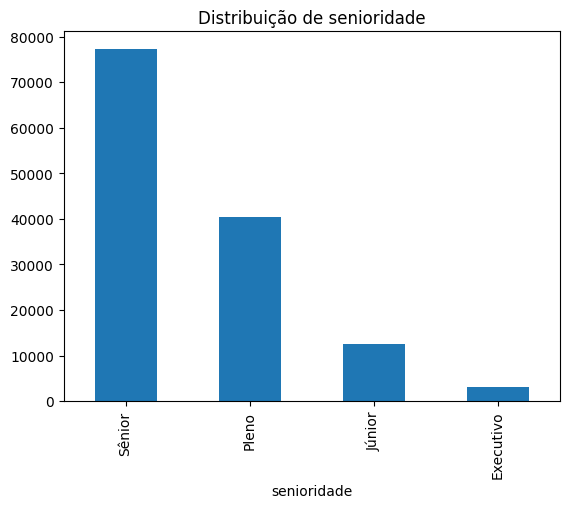

In [48]:
df_limpo['senioridade'].value_counts().plot(kind='bar', title = 'Distribuição de senioridade') #esse é o comando para gerar gráficos


#VAMOS UTILIZAR A METPLOTLIB E SEABORN
#SERÃO MELHORES PARA CUSTOMIZAR MEUS GRÁFICOS

In [49]:
import seaborn as sns


<Axes: xlabel='senioridade', ylabel='usd'>

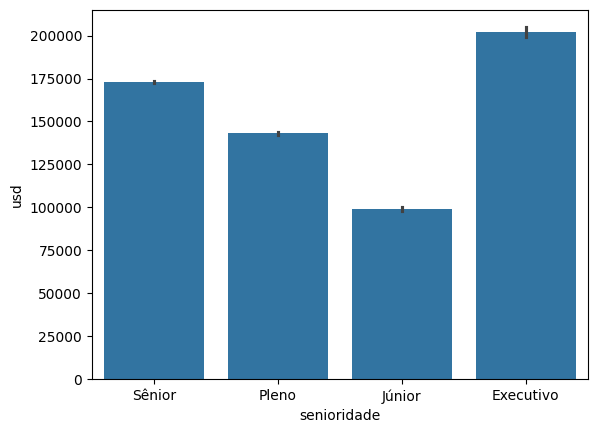

In [50]:
sns.barplot(data=df_limpo, x='senioridade', y='usd')

In [51]:
import matplotlib.pyplot as plt

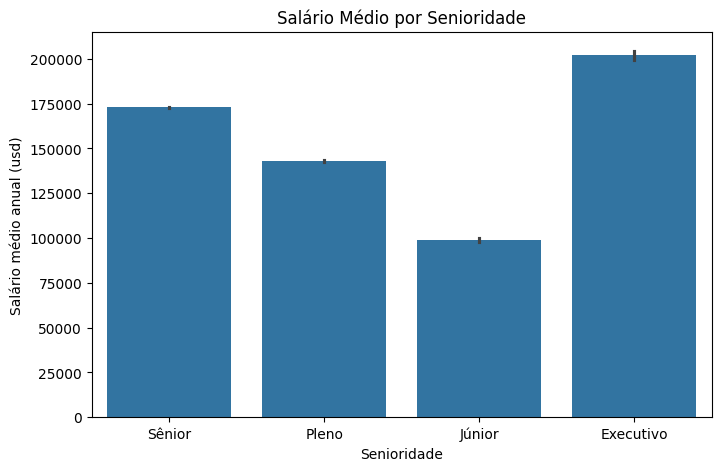

In [52]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senioridade', y='usd')
plt.title('Salário Médio por Senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário médio anual (usd)')
plt.savefig('graficos/salario Médio por Senioridade.png', dpi=300, bbox_inches='tight')
plt.show()


In [53]:
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

senioridade
Executivo    202027.667813
Sênior       172850.838301
Pleno        143044.845979
Júnior        99034.963267
Name: usd, dtype: float64

In [54]:
ordem = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=True).index #nessa linha, se acrescentarmos o True ou o False, vai ficar na ordem que quisermos.
ordem

Index(['Júnior', 'Pleno', 'Sênior', 'Executivo'], dtype='object', name='senioridade')

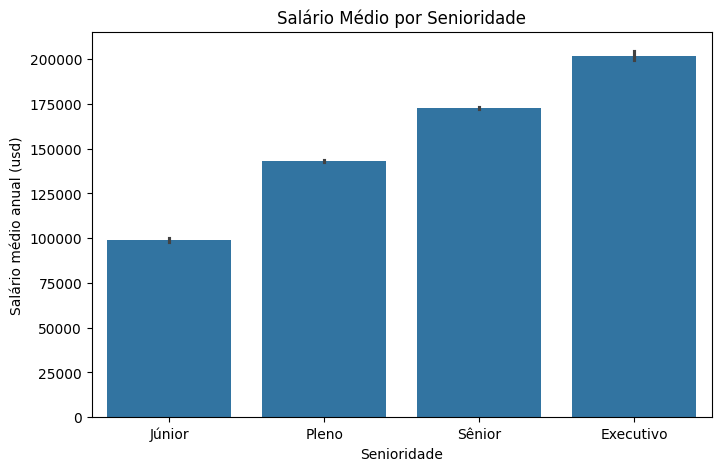

In [55]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', order=ordem)  #acrescentamos a ordem -> order = ordem
plt.title('Salário Médio por Senioridade')
plt.xlabel('Senioridade')
plt.ylabel('Salário médio anual (usd)')
plt.show()

PROCURE SEMPRE LEMBRAR DESSAS 4 FUNÇÕES:

plt.title('ALGO')

plt.xlabel('ALGO')

plt.ylabel('ALGO (usd)')

plt.show()

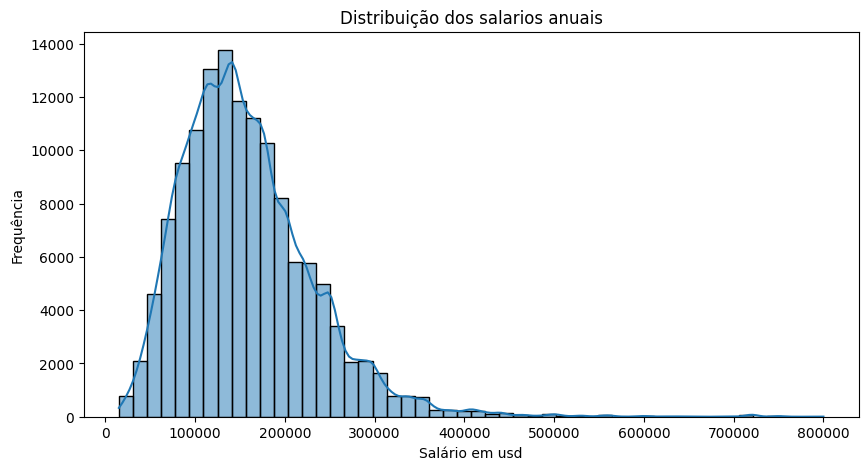

In [56]:
plt.figure(figsize=(10,5))
sns.histplot(df_limpo['usd'], bins=50, kde=True)  #bins: largura das barras; já o kde é uma linha azul que acompanha o histograma.
plt.title('Distribuição dos salarios anuais')
plt.xlabel('Salário em usd')
plt.ylabel('Frequência')
plt.savefig('graficos/Distribuição dos salários anuais.png', dpi=300, bbox_inches='tight')
plt.show()

#sns.barplot(data=df_limpo, x='contrato', y='usd'

#AGORA VAMOS CRIAR UM BLOXPOT

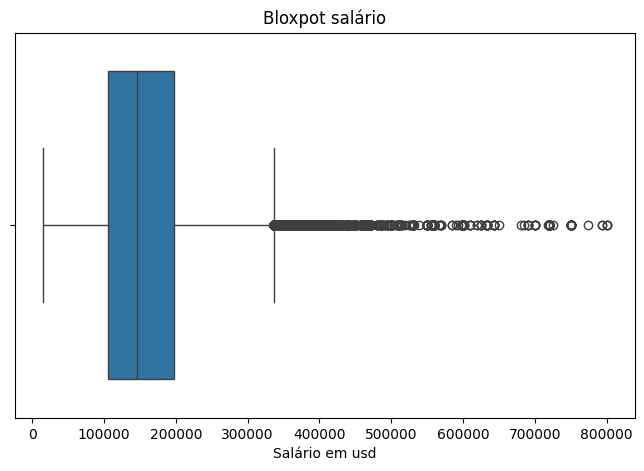

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_limpo['usd'])
plt.title('Bloxpot salário')
plt.xlabel('Salário em usd')
plt.savefig('graficos/Bloxpot salário.png', dpi=300, bbox_inches='tight')
plt.show()



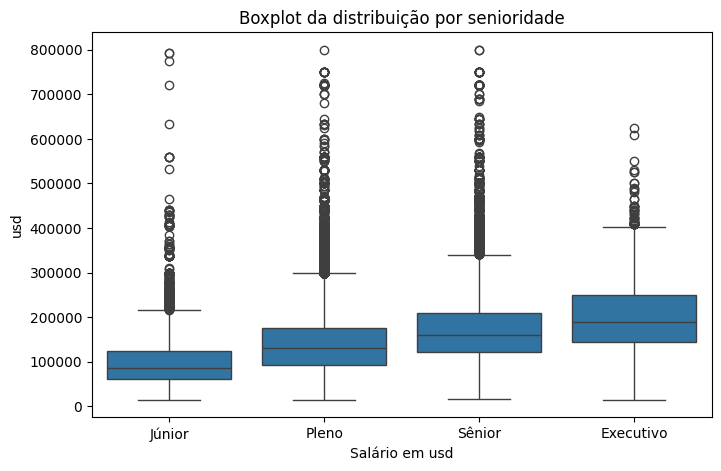

In [58]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior', 'Executivo'] # Corrected capitalization to match DataFrame values
plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade) # Corrected function name, string literals, and parameter name
plt.title('Boxplot da distribuição por senioridade')
plt.xlabel('Salário em usd')
plt.show()

#AGORA VAMOS COLOCAR CORES PARA CADA CAIXA

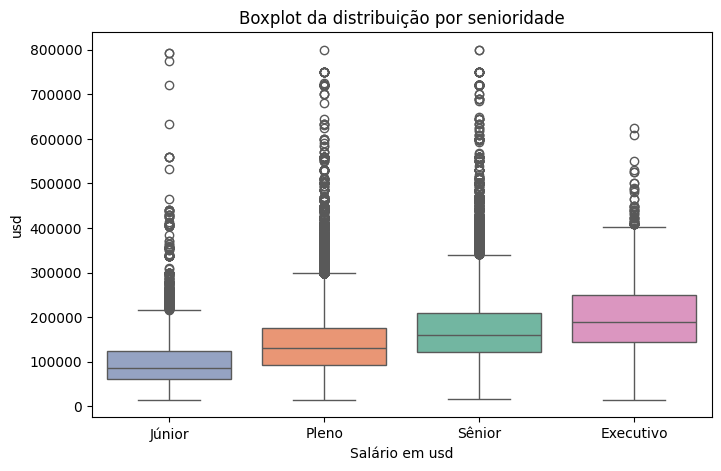

In [59]:
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior', 'Executivo']
plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade, palette = 'Set2', hue = 'senioridade') # 'senioridade' corrigido para minúsculas no parâmetro hue
plt.title('Boxplot da distribuição por senioridade')
plt.xlabel('Salário em usd')
plt.savefig('graficos/Bloxpot da distribuição por senioridade.png', dpi=300, bbox_inches='tight')
plt.show()

#CRIAÇÃO DE GRÁFICOS INTERATIVOS USANDO IA:

In [60]:
import plotly.express as px


In [61]:
df_media_salario_senioridade = df_limpo.groupby('senioridade')['usd'].mean().reset_index()

fig = px.bar(
    df_media_salario_senioridade,
    x='senioridade',
    y='usd',
    title='Salário Médio Anual por Senioridade (USD)',
    labels={'senioridade': 'Senioridade', 'usd': 'Salário Médio Anual (USD)'},
    category_orders={'senioridade': ['Júnior', 'Pleno', 'Sênior', 'Executivo']},
    color='senioridade', # Cor por senioridade para melhor distinção
    template='plotly_white' # Um tema limpo para o gráfico
)

fig.show()

#FAREMOS UM GRÁFICO DE PIZZA

In [62]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(remoto_contagem,
             names ='tipo_trabalho',
             values = 'quantidade',
             title = 'Proporção dos tipos de trabalho'
             )
fig.show()

In [63]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(remoto_contagem,
             names ='tipo_trabalho',
             values = 'quantidade',
             title = 'Proporção dos tipos de trabalho', hole = 0.5 #ao acrescenter o hole = 0.5, o gráfico se transforma em gráfico de pizza
             )
fig.show()

In [64]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']
fig = px.pie(remoto_contagem,
             names ='tipo_trabalho',
             values = 'quantidade',
             title = 'Proporção dos tipos de trabalho', hole = 0.5 #ao acrescenter o hole = 0.5, o gráfico se transforma em gráfico de pizza
             )
fig.update_traces(textinfo = 'percent + label')  #vai aparecer o nome e facilita a visualização, o que vai mudar com o passar dos anos.
fig.show()

## Conclusões e Aprendizados

Este projeto permitiu compreender, na prática, as etapas iniciais de um processo de análise de dados, desde a importação e tratamento dos dados até a criação de visualizações gráficas para análise.

Durante o desenvolvimento, foi possível aplicar conceitos importantes como:
- Limpeza e tratamento de dados
- Renomeação e organização de colunas
- Análise exploratória de dados
- Criação e personalização de gráficos
- Interpretação de dados para geração de insights

Além das habilidades técnicas, este projeto contribuiu para o desenvolvimento do raciocínio analítico, mostrando que a análise de dados não consiste apenas em programar, mas em fazer perguntas, interpretar resultados e transformar dados em informação útil para tomada de decisão.

Este projeto faz parte do meu processo de aprendizado em Análise de Dados com Python.